Laaouafi Fatiha

# Interpolation (Lagrange , Newton , Hermite)

### libraries

In [1]:
import sympy as sp 
import numpy as np
import matplotlib.pyplot as plt

## Lagrange

In [2]:
def Lfct(x, X, k):
    L = 1
    factors = []
    for i in range(len(X)):
        if i != k:
            L *= (x - X[i]) / (X[k] - X[i])
            factors.append("((x-" + str(X[i]) + ")/(" + str(X[k]) + "-" + str(X[i]) + "))")
    return L, "*".join(factors)


def lagrange(x, X, Y):
    S = 0
    terms = []
    for i in range(len(X)):
        Li, expr = Lfct(x, X, i)  
        S += Y[i] * Li
        terms.append(str(Y[i]) + "*" + expr)
    return S, " + ".join(terms)

### Test

In [3]:
XX = [1,3,10,7,8,5]

f = np.sin

X = [i  for i in  XX] # [ element   ]
Y = [f(i) for i in XX]

val, ply = lagrange( 5 , X , Y )
print()

print("the polynome of lagrange is : ",ply)
print()

print("the value is : ",val)

poly = sp.simplify(ply)
poly


the polynome of lagrange is :  0.8414709848078965*((x-3)/(1-3))*((x-10)/(1-10))*((x-7)/(1-7))*((x-8)/(1-8))*((x-5)/(1-5)) + 0.1411200080598672*((x-1)/(3-1))*((x-10)/(3-10))*((x-7)/(3-7))*((x-8)/(3-8))*((x-5)/(3-5)) + -0.5440211108893698*((x-1)/(10-1))*((x-3)/(10-3))*((x-7)/(10-7))*((x-8)/(10-8))*((x-5)/(10-5)) + 0.6569865987187891*((x-1)/(7-1))*((x-3)/(7-3))*((x-10)/(7-10))*((x-8)/(7-8))*((x-5)/(7-5)) + 0.9893582466233818*((x-1)/(8-1))*((x-3)/(8-3))*((x-10)/(8-10))*((x-7)/(8-7))*((x-5)/(8-5)) + -0.9589242746631385*((x-1)/(5-1))*((x-3)/(5-3))*((x-10)/(5-10))*((x-7)/(5-7))*((x-8)/(5-8))

the value is :  -0.9589242746631385


0.00353258894304425*x**5 - 0.1082841071733067*x**4 + 1.196914937415383*x**3 - 5.707472235138131*x**2 + 10.82374029060245*x - 5.36696048984154

### Plot lagrange polynial

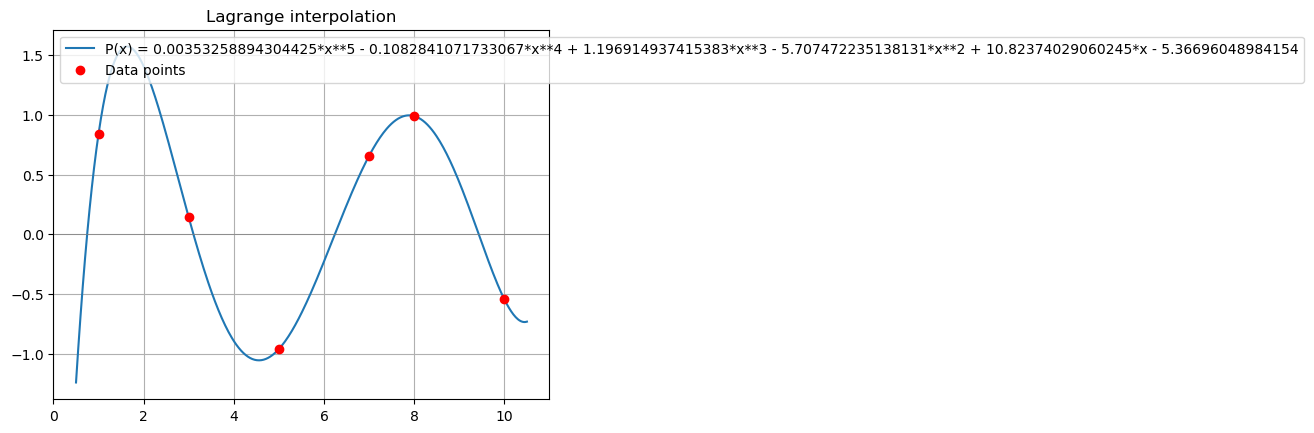

In [4]:
x = sp.symbols('x')
P = sp.lambdify(x, poly, 'numpy')

xs = np.linspace(min(X) - 0.5, max(X) + 0.5, 400)
ys = P(xs)


plt.plot(xs, ys, label=f"P(x) = {poly}")
plt.scatter(X, Y, color="red", zorder=5, label="Data points")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("Lagrange interpolation")
plt.legend()
plt.grid(True)
plt.show()

### Visualise the error

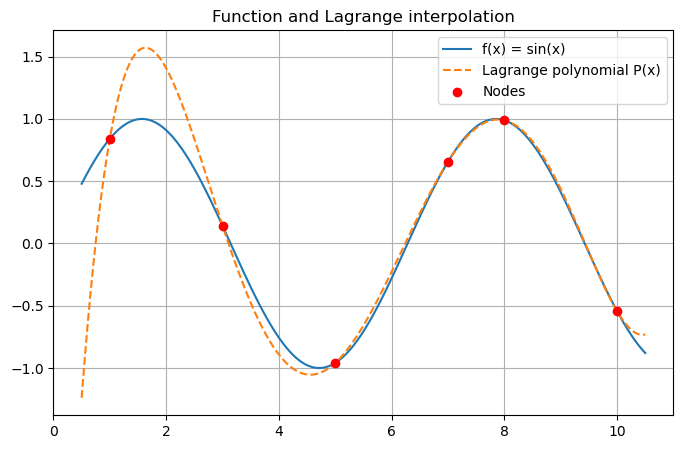

In [5]:
err = np.abs(f(xs) - P(xs))


plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), label="f(x) = sin(x)")
plt.plot(xs, P(xs), "--", label="Lagrange polynomial P(x)")
plt.scatter(X, Y, color="red", zorder=5, label="Nodes")
plt.legend()
plt.grid(True)
plt.title("Function and Lagrange interpolation")
plt.show()

## Newton

In [6]:
def div_diff(x, y):
    f = y.copy()

    for j in range(1, len(x)):
        for i in range(len(x) - 1, j - 1, -1):
            f[i] = (f[i] - f[i - 1]) / (x[i] - x[i - j])

    return f


def Newton(x, f, t):
    result = f[0]
    product = 1

    for i in range(1, len(f)):
        product *= (t - x[i - 1])
        result += f[i] * product

    return result

### Test

In [7]:
XX = [1,3,10,7,8,5]

f = np.sin

X = [i for i in XX]
Y = [f(i) for i in XX]

F = div_diff(X, Y)          

val = Newton(X, F, 5)
print("the value is : ", val)

x = sp.symbols('x')
polyN = sp.simplify(Newton(X, F, x))  
polyN

the value is :  -0.9589242746631386


0.00353258894304425*x**5 - 0.108284107173307*x**4 + 1.19691493741538*x**3 - 5.70747223513813*x**2 + 10.8237402906024*x - 5.36696048984154

### Plot Newton polynomial

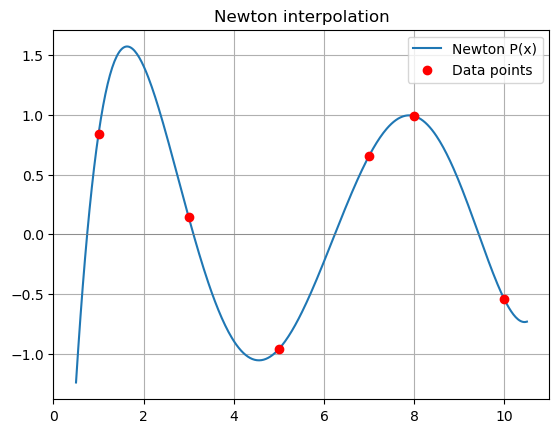

In [8]:
PN = sp.lambdify(x, polyN, 'numpy')

xs = np.linspace(min(X) - 0.5, max(X) + 0.5, 400)
ys = PN(xs)

plt.plot(xs, ys, label="Newton P(x)")
plt.scatter(X, Y, color="red", zorder=5, label="Data points")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("Newton interpolation")
plt.legend()
plt.grid(True)
plt.show()

### Visualise the error

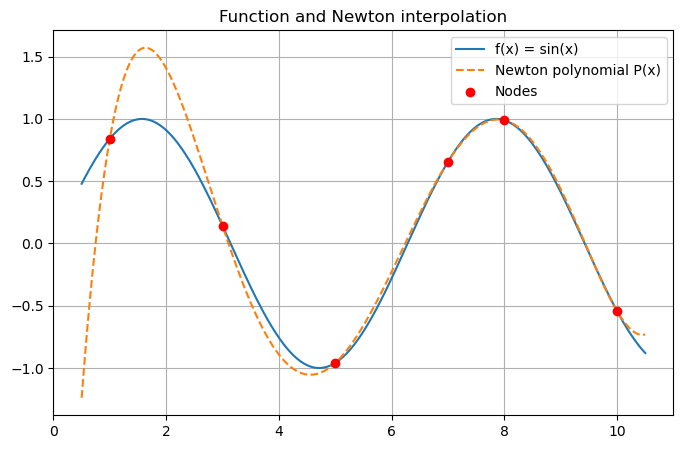

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), label="f(x) = sin(x)")
plt.plot(xs, PN(xs), "--", label="Newton polynomial P(x)")
plt.scatter(X, Y, color="red", zorder=5, label="Nodes")
plt.legend()
plt.grid(True)
plt.title("Function and Newton interpolation")
plt.show()

## Hermite

Hermite uses the values **and** the derivatives at each node. Each node is repeated twice, and the derivative is used where the two nodes are equal.

In [10]:
def hermite_div_diff(X, Y, dY):
    Z, F = [], []
    for i in range(len(X)):
        Z += [X[i], X[i]]         
        F += [Y[i], Y[i]]

    for j in range(1, len(Z)):
        for i in range(len(Z) - 1, j - 1, -1):
            if Z[i] == Z[i - j]:
                F[i] = dY[i // 2]
            else:
                F[i] = (F[i] - F[i - 1]) / (Z[i] - Z[i - j])
    return Z, F

### Test

In [11]:
X  = [0, 1, 2, 3]
f  = np.sin
df = np.cos                        

Y  = [f(i) for i in X]
dY = [df(i) for i in X]

Z, H = hermite_div_diff(X, Y, dY)

val = Newton(Z, H, 1.5)
print("the value is : ", val)

x = sp.symbols('x')
polyH = sp.simplify(Newton(Z, H, x))
polyH

the value is :  0.9974875823382363


x*(-1.30911228995162e-5*x**6 - 0.00112898958977004*x**5 + 0.011367559977402*x**4 - 0.00421794958057293*x**3 - 0.163725030545136*x**2 - 0.000811514331127389*x + 1.0)

### Plot Hermite polynomial and error

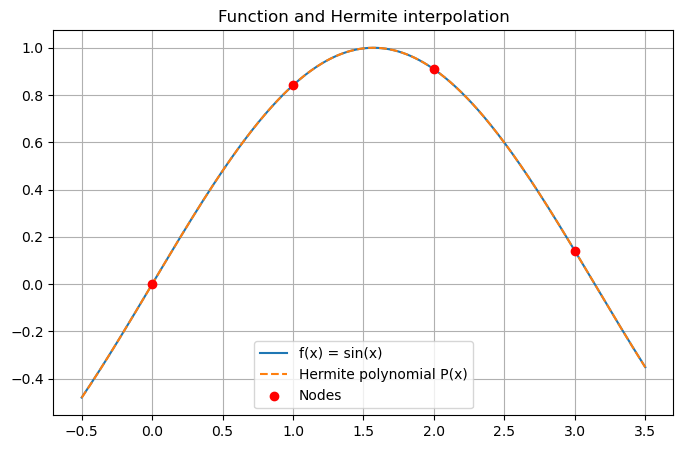

In [12]:
PH = sp.lambdify(x, polyH, 'numpy')

xs = np.linspace(min(X) - 0.5, max(X) + 0.5, 400)

plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), label="f(x) = sin(x)")
plt.plot(xs, PH(xs), "--", label="Hermite polynomial P(x)")
plt.scatter(X, Y, color="red", zorder=5, label="Nodes")
plt.legend()
plt.grid(True)
plt.title("Function and Hermite interpolation")
plt.show()

## La phenomenon of RUNGE

With equally spaced nodes, all three methods oscillate strongly near the ends of the interval,
and more nodes make it worse, not better. Lagrange and Newton give the same polynomial,
so their curves overlap. A fix is to use Chebyshev nodes or splines.